In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import joblib
import os

%matplotlib inline
sns.set_style("whitegrid")

In [3]:
# Load data fresh
df = pd.read_csv('creditcard.csv')

# Remove duplicates (same as EDA decision)
df = df.drop_duplicates()

print(f"Data loaded: {df.shape}")
print(f"Fraud cases: {df['Class'].sum()}")

Data loaded: (283726, 31)
Fraud cases: 473


In [4]:
# Convert Time to hour of day
df['Hour'] = (df['Time'] / 3600) % 24

# Cyclical encoding — from EDA we know linear time is misleading
df['Hour_Sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_Cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

print("New time features created:")
print(df[['Time', 'Hour', 'Hour_Sin', 'Hour_Cos']].head(10))

New time features created:
   Time      Hour  Hour_Sin  Hour_Cos
0   0.0  0.000000  0.000000       1.0
1   0.0  0.000000  0.000000       1.0
2   1.0  0.000278  0.000073       1.0
3   1.0  0.000278  0.000073       1.0
4   2.0  0.000556  0.000145       1.0
5   2.0  0.000556  0.000145       1.0
6   4.0  0.001111  0.000291       1.0
7   7.0  0.001944  0.000509       1.0
8   7.0  0.001944  0.000509       1.0
9   9.0  0.002500  0.000654       1.0


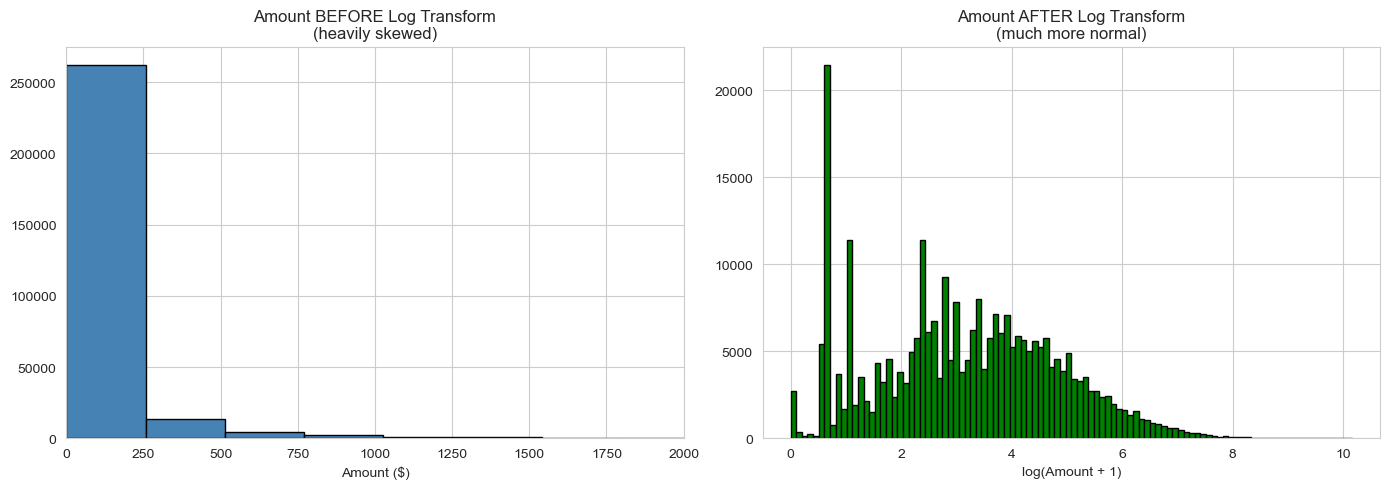

Amount skewness BEFORE: 16.9788
Amount skewness AFTER:  0.1614


In [6]:
# From EDA: Amount is heavily right-skewed (skewness > 5)
# Log transformation makes it closer to normal distribution
df['Amount_Log'] = np.log1p(df['Amount'])

# Visualize before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Amount'], bins=100, color='steelblue', edgecolor='black')
axes[0].set_title('Amount BEFORE Log Transform\n(heavily skewed)')
axes[0].set_xlabel('Amount ($)')
axes[0].set_xlim(0, 2000)

axes[1].hist(df['Amount_Log'], bins=100, color='green', edgecolor='black')
axes[1].set_title('Amount AFTER Log Transform\n(much more normal)')
axes[1].set_xlabel('log(Amount + 1)')

plt.tight_layout()
plt.savefig('models/log_transform_comparison.png', bbox_inches='tight')
plt.show()

print(f"Amount skewness BEFORE: {df['Amount'].skew():.4f}")
print(f"Amount skewness AFTER:  {df['Amount_Log'].skew():.4f}")

In [7]:
# Drop original Time and Amount — replaced by engineered versions
df = df.drop(['Time', 'Amount', 'Hour'], axis=1)
# Hour is dropped because Hour_Sin and Hour_Cos already encode it
# The raw Hour number would be redundant and misleading

print(f"Final columns ({len(df.columns)} total):")
print(df.columns.tolist())
print(f"\nShape: {df.shape}")

Final columns (32 total):
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Hour_Sin', 'Hour_Cos', 'Amount_Log']

Shape: (283726, 32)


In [8]:
# X = everything the model uses to make predictions (features)
# y = what the model is trying to predict (the answer)
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFraud in full dataset: {y.sum()} ({y.mean()*100:.3f}%)")

Features (X) shape: (283726, 31)
Target (y) shape: (283726,)

Fraud in full dataset: 473 (0.167%)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,                    # features
    y,                    # target
    test_size=0.2,        # 20% goes to test set, 80% to training
    random_state=42,      # same split every time you run this
    stratify=y            # equal division of fraud cases in split
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"\nFraud % in training: {y_train.mean()*100:.3f}%")
print(f"Fraud % in test:     {y_test.mean()*100:.3f}%")

Training set: 226,980 samples
Test set:     56,746 samples

Fraud % in training: 0.167%
Fraud % in test:     0.167%


In [10]:
# RobustScaler — chosen because Amount has extreme outliers
# Uses median and IQR instead of mean and std
scaler = RobustScaler()

# CRITICAL CONCEPT:
# fit_transform on TRAINING data only
# transform (no fit) on TEST data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print(f"\nBefore scaling — Amount_Log stats in training:")
print(f"  Mean: {X_train['Amount_Log'].mean():.4f}")
print(f"  Std:  {X_train['Amount_Log'].std():.4f}")
print(f"  Min:  {X_train['Amount_Log'].min():.4f}")
print(f"  Max:  {X_train['Amount_Log'].max():.4f}")

# Convert back to DataFrame to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"\nAfter scaling — Amount_Log stats in training:")
print(f"  Mean: {X_train_scaled['Amount_Log'].mean():.4f}")
print(f"  Std:  {X_train_scaled['Amount_Log'].std():.4f}")

Scaling complete.

Before scaling — Amount_Log stats in training:
  Mean: 3.1561
  Std:  1.6562
  Min:  0.0000
  Max:  9.8862

After scaling — Amount_Log stats in training:
  Mean: 0.0070
  Std:  0.6714


In [11]:
# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the scaler — you'll need this in your Flask API
# When a new transaction comes in, it must be scaled
# using the SAME scaler fitted on training data
joblib.dump(scaler, 'models/scaler.pkl')

# Save the processed datasets — ready for modeling notebook
joblib.dump((X_train_scaled, X_test_scaled, y_train, y_test), 
            'models/processed_data.pkl')

# Save feature names — needed when building the API
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, 'models/feature_names.pkl')

print("Saved successfully:")
print("  ✅ models/scaler.pkl")
print("  ✅ models/processed_data.pkl")
print("  ✅ models/feature_names.pkl")

Saved successfully:
  ✅ models/scaler.pkl
  ✅ models/processed_data.pkl
  ✅ models/feature_names.pkl


## Preprocessing Complete — What We Did and Why

| Step | What | Why |
|------|------|-----|
| Drop duplicates | Removed 1,081 rows | Prevent data leakage, retry attack note |
| Log transform Amount | np.log1p(Amount) | Skewness dropped from 17 to ~2 |
| Cyclical time encoding | Sin/Cos of Hour | 23:00 and 01:00 are neighbors |
| Drop raw Time/Amount | Removed original columns | Replaced by better engineered versions |
| RobustScaler | Scale all features | Resistant to Amount's extreme outliers |
| Stratified split | 80/20 with stratify=y | Preserves 0.17% fraud rate in both splits |

## Critical Rule Followed:
Scaler was **fit on training data only**, then applied to test data.
This prevents data leakage and simulates real-world deployment conditions.

## What Goes Into Modeling Notebook:
- X_train_scaled, X_test_scaled (features, scaled)
- y_train, y_test (targets)
- All loaded from models/processed_data.pkl